In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    auc
)

In [ ]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn (1).csv


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# Drop customerID
df.drop("customerID", axis=1, inplace=True)

# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

# Encode categorical columns
le = LabelEncoder()
for col in df.select_dtypes(include=["object"]).columns:
    df[col] = le.fit_transform(df[col])

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


In [ ]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale data for Logistic Regression & SVM
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(probability=True)
}

results = {}

for name, model in models.items():

    if name in ["Logistic Regression", "SVM"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:,1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:,1]

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    results[name] = {
        "Accuracy": acc,
        "F1 Score": f1,
        "AUC": roc_auc,
        "Confusion Matrix": cm,
        "FPR": fpr,
        "TPR": tpr
    }

In [ ]:
results_df = pd.DataFrame(results).T
results_df[["Accuracy", "F1 Score", "AUC"]]

,Accuracy,F1 Score,AUC
Logistic Regression,0.815472,0.624277,0.861355
Random Forest,0.790632,0.541213,0.832556
SVM,0.806955,0.578947,0.813162


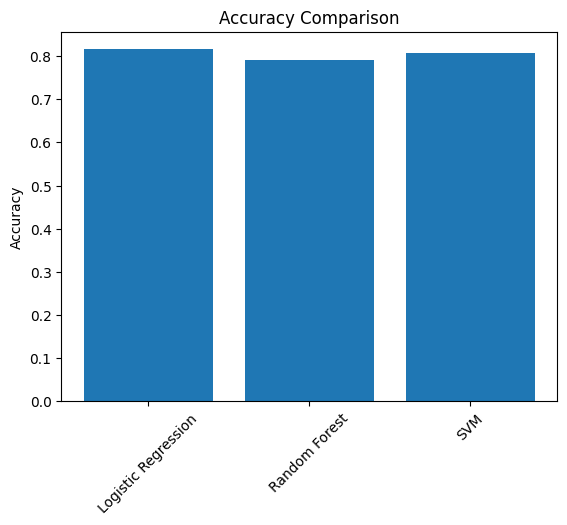

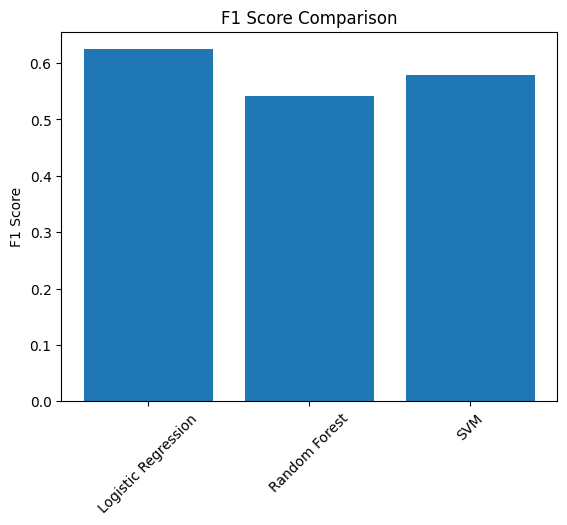

In [ ]:
# Accuracy
plt.figure()
plt.bar(results_df.index, results_df["Accuracy"])
plt.xticks(rotation=45)
plt.title("Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

# F1 Score
plt.figure()
plt.bar(results_df.index, results_df["F1 Score"])
plt.xticks(rotation=45)
plt.title("F1 Score Comparison")
plt.ylabel("F1 Score")
plt.show()

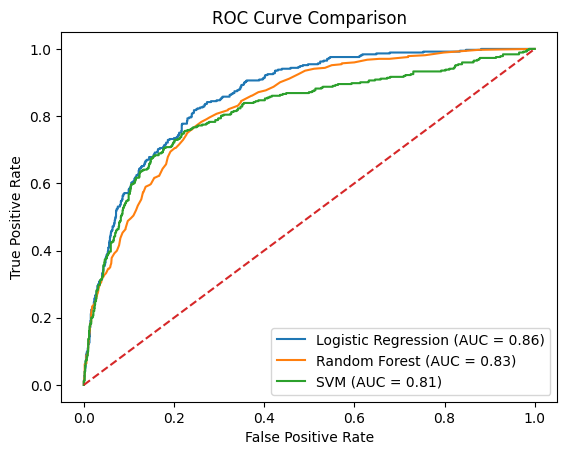

In [ ]:
plt.figure()

for name in results:
    plt.plot(
        results[name]["FPR"],
        results[name]["TPR"],
        label=f"{name} (AUC = {results[name]['AUC']:.2f})"
    )

plt.plot([0,1], [0,1], '--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

Best Model based on AUC: Logistic Regression


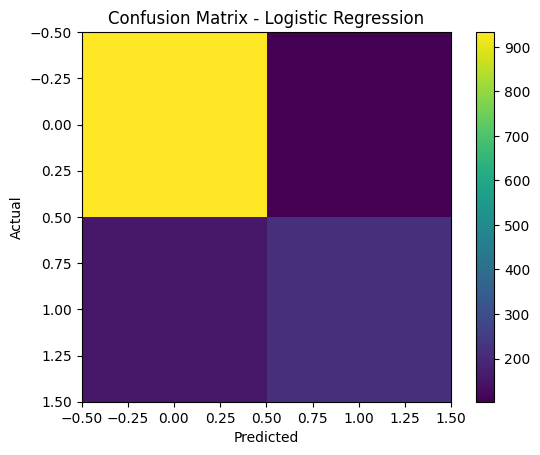

In [ ]:
best_model = results_df["AUC"].idxmax()
print("Best Model based on AUC:", best_model)

cm = results[best_model]["Confusion Matrix"]

plt.figure()
plt.imshow(cm)
plt.title(f"Confusion Matrix - {best_model}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

/tmp/ipython-input-360/1859673691.py:31: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(x[i] - width, results_df["Accuracy"][i],
/tmp/ipython-input-360/1859673691.py:32: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  f"{results_df['Accuracy'][i]:.2f}", ha='center', va='bottom')
/tmp/ipython-input-360/1859673691.py:34: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(x[i], results_df["F1 Score"][i],
/tmp/ipython-input-36

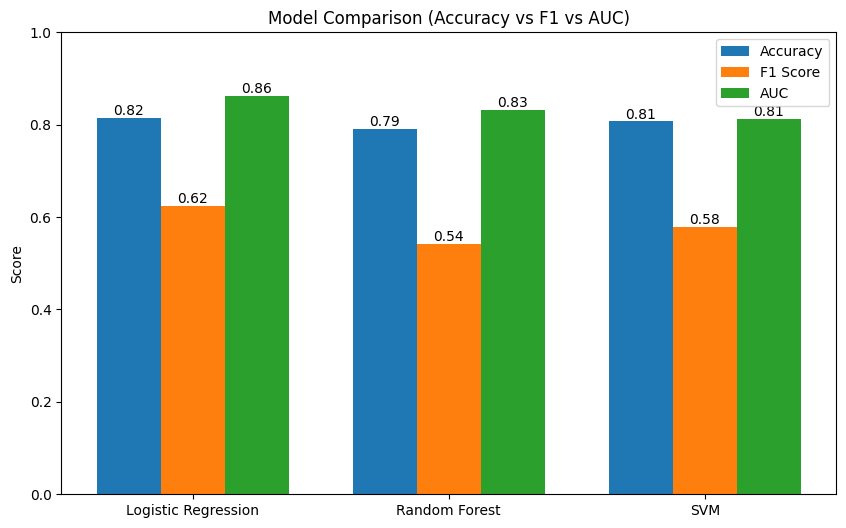

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Convert results to DataFrame
results_df = pd.DataFrame(results).T

# Metrics to plot
metrics = ["Accuracy", "F1 Score", "AUC"]
models = results_df.index

# X-axis positions
x = np.arange(len(models))
width = 0.25

# Create figure
plt.figure(figsize=(10,6))

# Plot bars
plt.bar(x - width, results_df["Accuracy"], width, label="Accuracy")
plt.bar(x, results_df["F1 Score"], width, label="F1 Score")
plt.bar(x + width, results_df["AUC"], width, label="AUC")

# Labels & Title
plt.xticks(x, models)
plt.ylabel("Score")
plt.title("Model Comparison (Accuracy vs F1 vs AUC)")
plt.legend()

# Show values on bars
for i in range(len(models)):
    plt.text(x[i] - width, results_df["Accuracy"][i],
             f"{results_df['Accuracy'][i]:.2f}", ha='center', va='bottom')

    plt.text(x[i], results_df["F1 Score"][i],
             f"{results_df['F1 Score'][i]:.2f}", ha='center', va='bottom')

    plt.text(x[i] + width, results_df["AUC"][i],
             f"{results_df['AUC'][i]:.2f}", ha='center', va='bottom')

plt.ylim(0,1)
plt.show()